**Crab Age Prediction (Yengeç Yaşı Tahmini)**


**Proje Amacı**

Bu projenin temel amacı, yengeçlerin fiziksel özelliklerini (boyut, ağırlık ve cinsiyet) kullanarak yaşlarını (Age) en doğru şekilde tahmin edebilecek bir makine öğrenmesi modeli geliştirmektir.

**Problemin Tanımı**

Deniz biyolojisinde bir yengecin yaşını belirlemek için genellikle kabuğunun kesilmesi ve mikroskop altında incelenmesi gerekir. Bu yöntem hem maliyetlidir hem de zaman alıcıdır.
Bizim hedefimiz; yengece zarar vermeden, sadece dışarıdan yapılabilecek fiziksel ölçümlerle (Boy, Çap, Yükseklik ve çeşitli Ağırlık birimleri) bu süreci dijitalleştirmek ve otomatize etmektir.

**Teknik Hedefler**

Regresyon Analizi: Hedef değişkenimiz sürekli bir sayısal değer (Yaş) olduğu için bir regresyon problemi çözüyoruz.

Hata Payını Minimize Etme: Tahminlerimizin gerçek yaşa ne kadar yakın olduğunu ölçmek için MAE (Mean Absolute Error) metriğini kullanacağız. Hedefimiz MAE değerini mümkün olan en düşük seviyeye çekmektir.

Özellik Mühendisliği (Feature Engineering): Mevcut fiziksel ölçümlerden (örneğin: Ağırlık / Boy oranı) yeni anlamlı veriler türeterek modelin başarısını artırmak.

Model Dağıtımı (Deployment): Eğitilen modeli Streamlit ve Hugging Face üzerinden son kullanıcının (örneğin bir araştırmacının) verileri girip sonuç alabileceği bir arayüze dönüştürmek.


<img src='https://media.istockphoto.com/id/544453032/tr/foto%C4%9Fraf/crab-close-up-cuba.jpg?s=612x612&w=0&k=20&c=ptHTZJCbUqi6HKSyWQdQxCmzXqwHXIZ_uunsg8VnzPc='>

In [1]:
# Veri analizi, matris işlemleri ve görselleştirme için gerekli temel kütüphaneleri yüklüyoruz.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Etkileşimli grafikler ve model hata analizi (residual) için gelişmiş kütüphaneleri ekliyoruz.
import plotly.express as px
from yellowbrick.regressor import ResidualsPlot

In [2]:
#veriyi oku

df=pd.read_csv('train.csv')

# EDA

In [3]:
#ilk 5 satırı göster

df.head()

,id,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
0,0,I,1.5250,1.1750,0.3750,28.973189,12.728926,6.647958,8.348928,9
1,1,I,1.1000,0.8250,0.2750,10.418441,4.521745,2.324659,3.401940,8
2,2,M,1.3875,1.1125,0.3750,24.777463,11.339800,5.556502,6.662133,9
3,3,F,1.7000,1.4125,0.5000,50.660556,20.354941,10.991839,14.996885,11
4,4,I,1.2500,1.0125,0.3375,23.289114,11.977664,4.507570,5.953395,8


In [4]:
#son 5 satırı göster

df.tail()

,id,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
74046,74046,F,1.6625,1.2625,0.4375,50.660556,20.680960,10.361742,12.332033,10
74047,74047,I,1.0750,0.8625,0.2750,10.446791,4.323299,2.296310,3.543687,6
74048,74048,F,1.4875,1.2000,0.4125,29.483480,12.303683,7.540967,8.079607,10
74049,74049,I,1.2125,0.9625,0.3125,16.768729,8.972617,2.919999,4.280774,8
74050,74050,I,0.9125,0.6750,0.2000,5.386405,2.055339,1.034757,1.700970,6


In [5]:
#kaç satır kaç sütun?

df.shape

(74051, 10)

In [6]:
#veriler hakkında bilgi

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74051 entries, 0 to 74050
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              74051 non-null  int64  
 1   Sex             74051 non-null  object 
 2   Length          74051 non-null  float64
 3   Diameter        74051 non-null  float64
 4   Height          74051 non-null  float64
 5   Weight          74051 non-null  float64
 6   Shucked Weight  74051 non-null  float64
 7   Viscera Weight  74051 non-null  float64
 8   Shell Weight    74051 non-null  float64
 9   Age             74051 non-null  int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 5.6+ MB


In [7]:
#boş veri kontrolü

df.isnull().sum()

id                0
Sex               0
Length            0
Diameter          0
Height            0
Weight            0
Shucked Weight    0
Viscera Weight    0
Shell Weight      0
Age               0
dtype: int64

In [8]:
#korelasyon, veriler arası bağlantı
df.corr(numeric_only=True)

,id,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
id,1.000000,0.000165,0.000290,0.000967,-0.000910,-0.000801,-0.000640,-0.000816,0.000089
Length,0.000165,1.000000,0.989437,0.918352,0.936374,0.915516,0.917855,0.916957,0.612843
Diameter,0.000290,0.989437,1.000000,0.921353,0.938249,0.914199,0.918351,0.922688,0.621256
Height,0.000967,0.918352,0.921353,1.000000,0.901775,0.864083,0.883127,0.903398,0.638067
Weight,-0.000910,0.936374,0.938249,0.901775,1.000000,0.971267,0.971062,0.965525,0.601195
Shucked Weight,-0.000801,0.915516,0.914199,0.864083,0.971267,1.000000,0.942626,0.910398,0.503320
Viscera Weight,-0.000640,0.917855,0.918351,0.883127,0.971062,0.942626,1.000000,0.933919,0.576808
Shell Weight,-0.000816,0.916957,0.922688,0.903398,0.965525,0.910398,0.933919,1.000000,0.663473
Age,0.000089,0.612843,0.621256,0.638067,0.601195,0.503320,0.576808,0.663473,1.000000


In [9]:
#verilerin istatiksel bilgileri
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,74051.0,37025.000000,21376.826729,0.000000,18512.500000,37025.000000,55537.500000,74050.000000
Length,74051.0,1.317460,0.287757,0.187500,1.150000,1.375000,1.537500,2.012815
Diameter,74051.0,1.024496,0.237396,0.137500,0.887500,1.075000,1.200000,1.612500
Height,74051.0,0.348089,0.092034,0.000000,0.300000,0.362500,0.412500,2.825000
Weight,74051.0,23.385217,12.648153,0.056699,13.437663,23.799405,32.162508,80.101512
Shucked Weight,74051.0,10.104270,5.618025,0.028349,5.712424,9.908150,14.033003,42.184056
Viscera Weight,74051.0,5.058386,2.792729,0.042524,2.863300,4.989512,6.988152,21.545620
Shell Weight,74051.0,6.723870,3.584372,0.042524,3.968930,6.931453,9.071840,28.491248
Age,74051.0,9.967806,3.175189,1.000000,8.000000,10.000000,11.000000,29.000000


# Görselleştirme

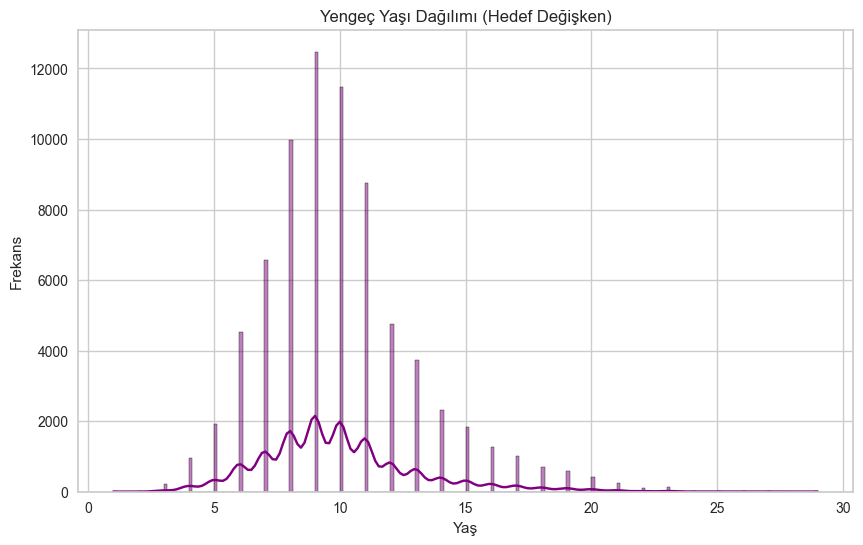

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, color='purple')
plt.title('Yengeç Yaşı Dağılımı (Hedef Değişken)')
plt.xlabel('Yaş')
plt.ylabel('Frekans')
plt.show()

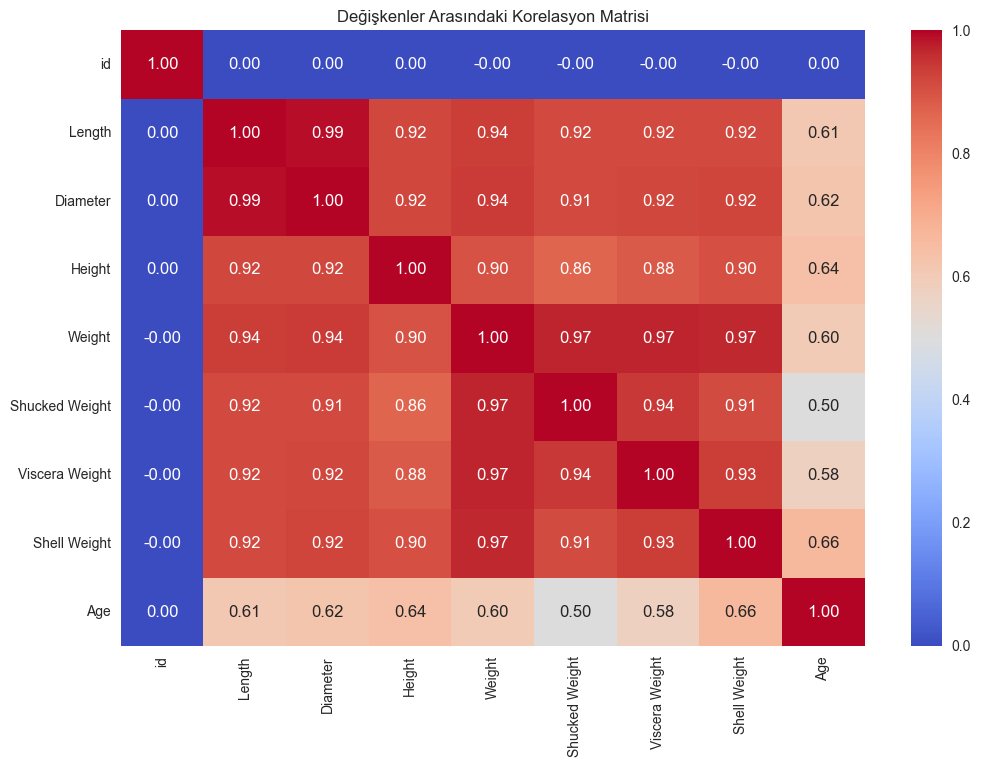

In [11]:
plt.figure(figsize=(12, 8))
# annot=True: Karelerin içine sayıları yazar
# fmt='.2f': Virgülden sonra 2 basamak gösterir
# cmap='coolwarm': Renk paleti (mavi-kırmızı) ilişkileri daha net gösterir
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Değişkenler Arasındaki Korelasyon Matrisi')
plt.show()

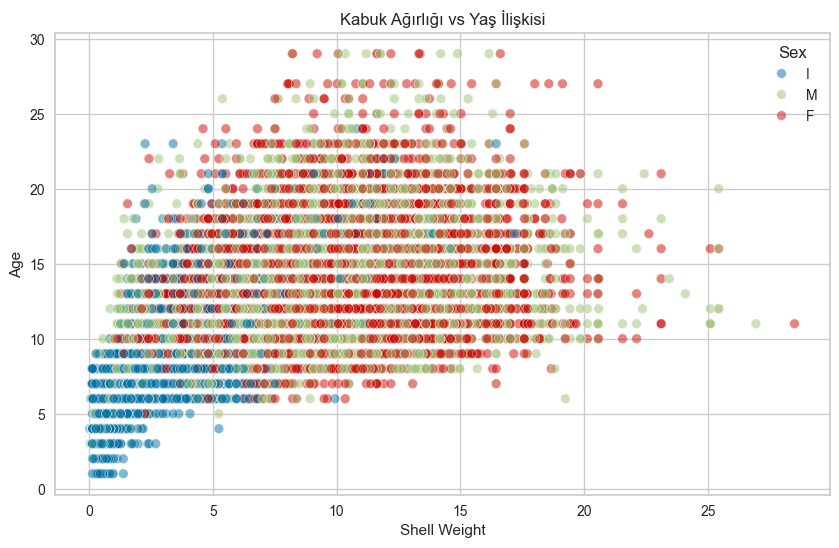

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Shell Weight', y='Age', hue='Sex', alpha=0.5)
plt.title('Kabuk Ağırlığı vs Yaş İlişkisi')
plt.show()

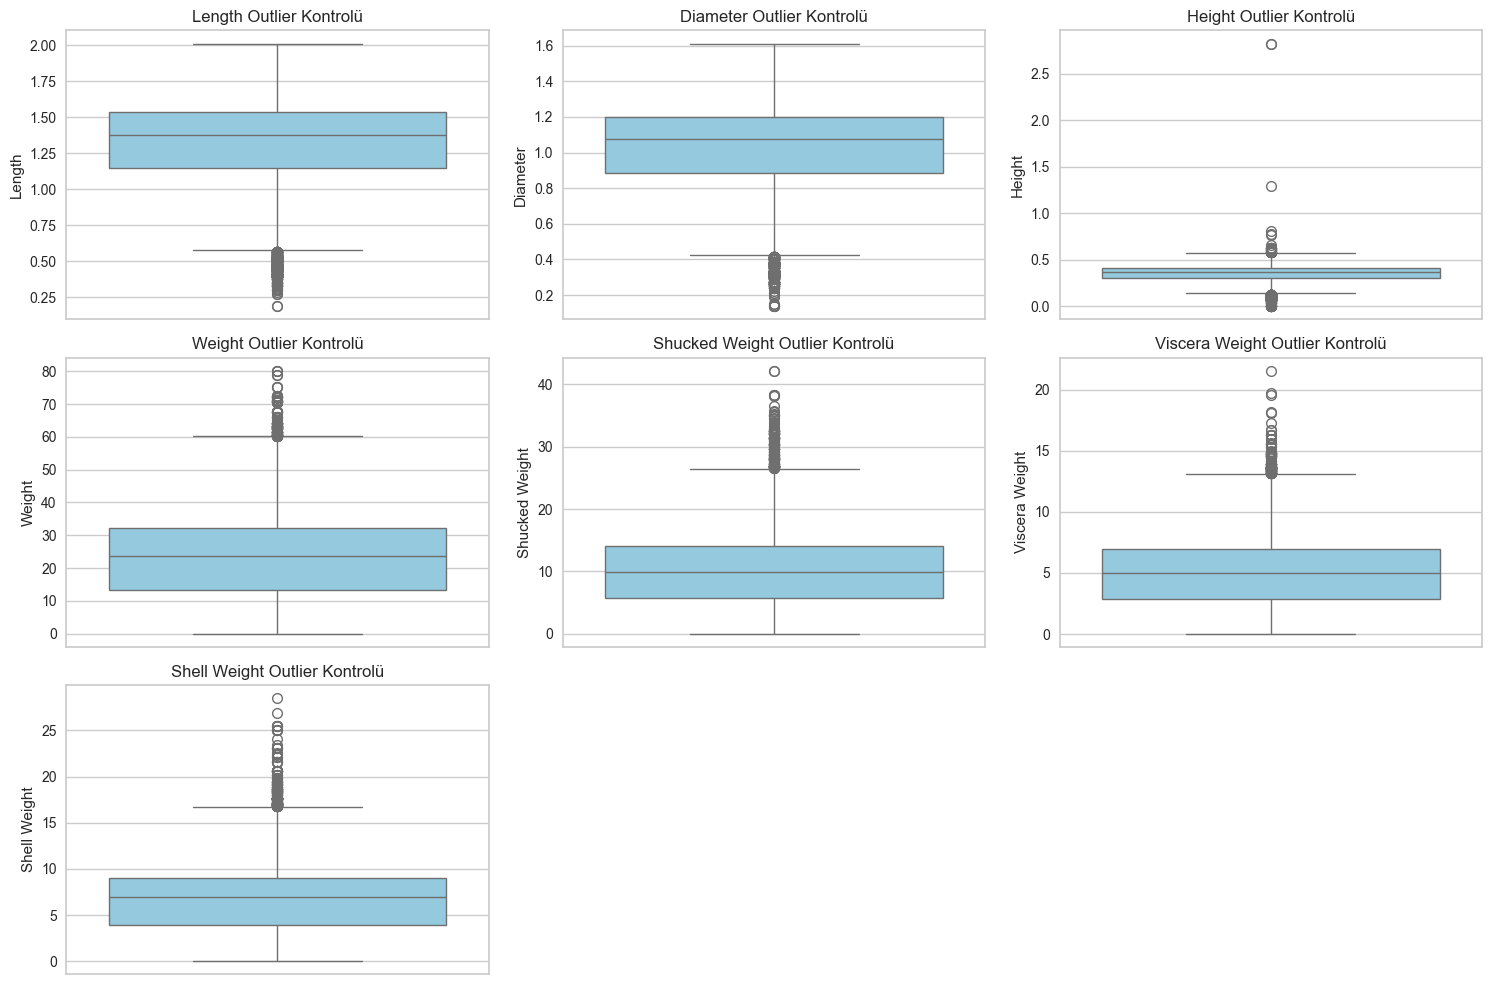

In [13]:
# Sayısal sütunları seçelim (id ve Age hariç)
features = ['Length', 'Diameter', 'Height', 'Weight', 'Shucked Weight', 'Viscera Weight', 'Shell Weight']

# Görselleştirme
plt.figure(figsize=(15, 10))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, y=col, color='skyblue')
    plt.title(f'{col} Outlier Kontrolü')

plt.tight_layout()
plt.show()

In [14]:
#outliers temizliği 

def clean_outliers_capping(df, columns):
    df_cleaned = df.copy() # Orijinal veriyi bozmamak için kopya alalım
    for col in columns:
        Q1 = df[col].quantile(0.28)
        Q3 = df[col].quantile(0.72)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Sınırların dışındakileri silme, sınıra eşitle!
        df_cleaned[col] = df_cleaned[col].clip(lower=lower_bound, upper=upper_bound)
        
    return df_cleaned

# Önce hangi sütunları temizleyeceğimizi seçelim
features = ['Length', 'Diameter', 'Height', 'Weight', 'Shucked Weight', 'Viscera Weight', 'Shell Weight']

# FONKSİYONU ÇALIŞTIR VE SONUCU df_cleaned DEĞİŞKENİNE ATAMASINI YAP 
df_cleaned = clean_outliers_capping(df, features)

In [15]:
print(f"Orijinal veri boyutu: {df.shape}")
print(f"Temizlenmiş veri boyutu: {df_cleaned.shape}")
print(f"Kaybolan veri oranı: %{100 * (len(df) - len(df_cleaned)) / len(df):.2f}")

Orijinal veri boyutu: (74051, 10)
Temizlenmiş veri boyutu: (74051, 10)
Kaybolan veri oranı: %0.00


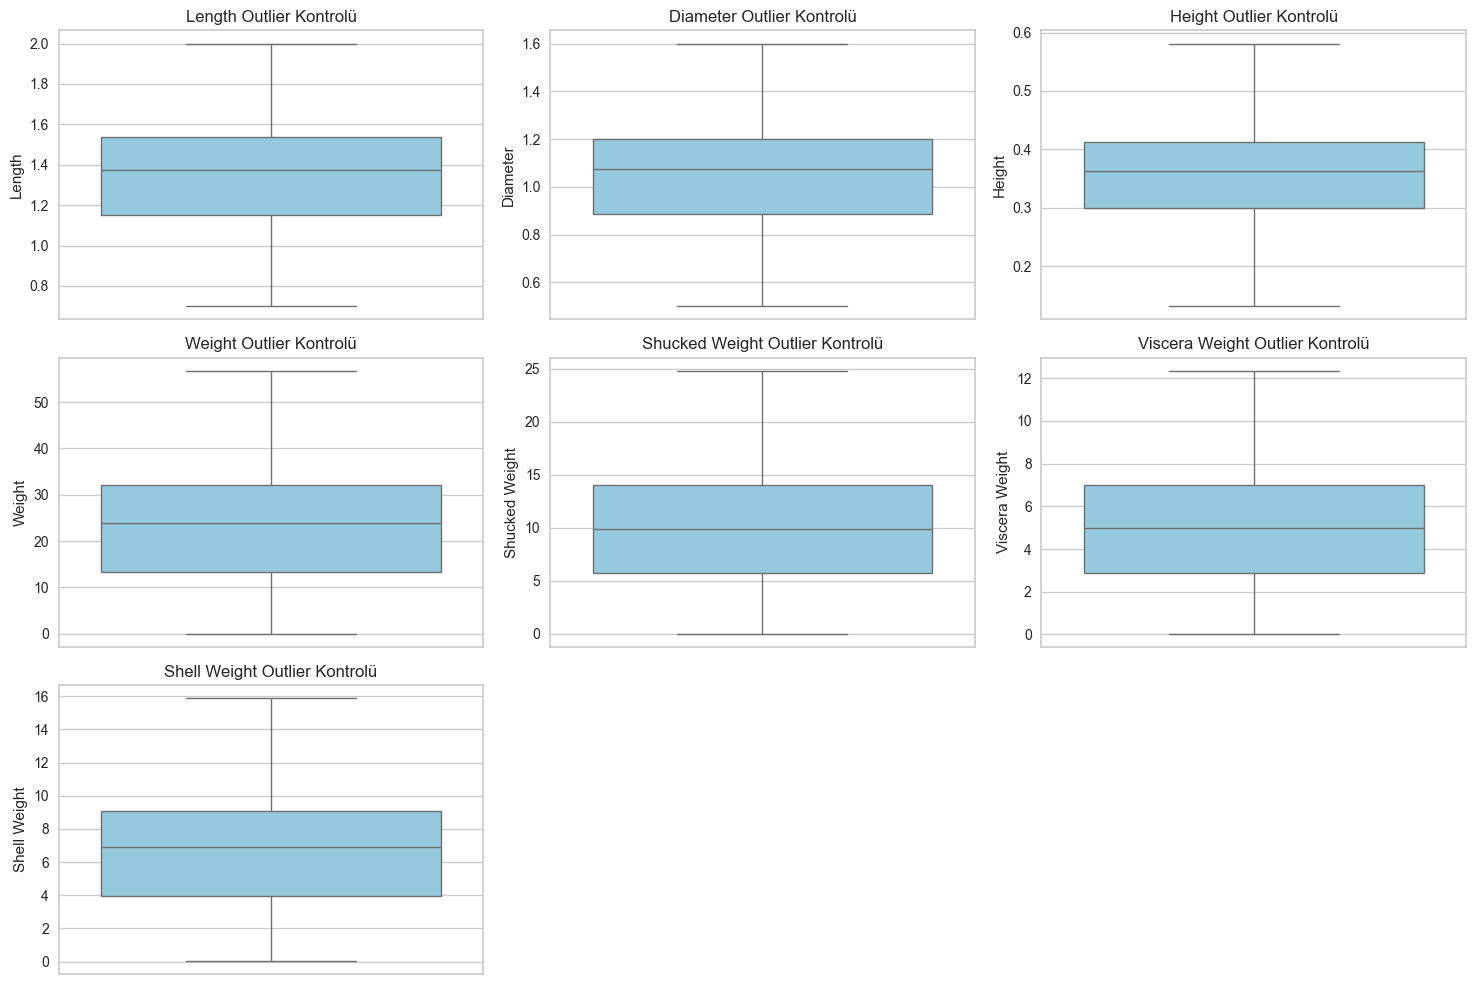

In [16]:
# Sayısal sütunları seçelim (id ve Age hariç)
features = ['Length', 'Diameter', 'Height', 'Weight', 'Shucked Weight', 'Viscera Weight', 'Shell Weight']

# Görselleştirme
plt.figure(figsize=(15, 10))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df_cleaned, y=col, color='skyblue')
    plt.title(f'{col} Outlier Kontrolü')

plt.tight_layout()
plt.show()

# Feature Engineering

In [17]:
# sadece imkansız değerleri (yüksekliği 0 olanları) silelim
df_cleaned = df[df['Height'] > 0].copy()

In [18]:
# 1. Kabuk Ağırlığı Oranı (Shell Weight / Total Weight)
# Yaşla korelasyonu en yüksek olan Shell Weight'i toplam ağırlığa oranlıyoruz.
#Sıfıra bölme hatasını engellemek için 0.001 kullanıyoruz
df_cleaned['Shell_Weight_Ratio'] = df_cleaned['Shell Weight'] / (df_cleaned['Weight'] + 0.001)

In [19]:
# 2. Et Verimi (Shucked Weight / Total Weight)
# Kabuksuz ağırlığın toplam ağırlığa oranı yengecin olgunluğunu gösterir.
df_cleaned['Meat_Yield'] = df_cleaned['Shucked Weight'] / (df_cleaned['Weight'] + 0.001)    

In [20]:
# 3. Tahmini Geometrik Hacim (Length * Diameter * Height)
# Boyutları tek bir "hacim" değişkeninde birleştiriyoruz.
df_cleaned['Volume'] = df_cleaned['Length'] * df_cleaned['Diameter'] * df['Height']

In [21]:
# 4. Yoğunluk (Ağırlık / Hacim)
# Aynı boyuttaki yengeçlerden daha ağır olanı genellikle daha yaşlıdır.
df_cleaned['Density'] = df_cleaned['Weight'] / (df_cleaned['Volume'] + 0.001)    

In [22]:
# 5. Parça Ağırlığı Tutarlılığı
# Parçaların toplamı ile ana ağırlık farkını hesaplayalım.
df_cleaned['Weight_Diff'] = df_cleaned['Weight'] - (df_cleaned['Shucked Weight'] + df_cleaned['Viscera Weight'] + df_cleaned['Shell Weight'])  

In [23]:
#İç organ oranı, sağlık ve yaş göstergesidir
df_cleaned['Viscera_Ratio'] = df_cleaned['Viscera Weight'] / df_cleaned['Weight']

In [24]:
# Yengecin form faktörü
df_cleaned['Shape_Index'] = df_cleaned['Length'] / (df_cleaned['Height'] + 0.001)

In [25]:
#Shell_to_Total: Kabuğun toplam ağırlıktaki baskınlığı (En güçlü sinyal!)
df_cleaned['Shell_to_Total'] = df_cleaned['Shell Weight'] / (df_cleaned['Weight'] + 0.001)

In [26]:
#Dimensions_Sum: Toplam boyut endeksi
df_cleaned['Dim_Sum'] = df_cleaned['Length'] + df_cleaned['Diameter'] + df_cleaned['Height']

In [27]:
#cinsiyet sütunu değerlerini inceleme

df_cleaned['Sex'].value_counts()

Sex
M    27084
I    23933
F    23010
Name: count, dtype: int64

In [28]:
#cinsiyet sütununu sayısala çevirelim

df_cleaned=pd.get_dummies(df_cleaned, columns=['Sex'], prefix='Sex')

In [29]:
# XGBoost Hata Vermesin Diye Her Şeyi Float Yap
# Bu satır, bool (True/False) olanları da 1.0 ve 0.0 yapacağı için XGBoost çok rahatlar.
df_cleaned = df_cleaned.astype(float)

In [30]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74027 entries, 0 to 74050
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  74027 non-null  float64
 1   Length              74027 non-null  float64
 2   Diameter            74027 non-null  float64
 3   Height              74027 non-null  float64
 4   Weight              74027 non-null  float64
 5   Shucked Weight      74027 non-null  float64
 6   Viscera Weight      74027 non-null  float64
 7   Shell Weight        74027 non-null  float64
 8   Age                 74027 non-null  float64
 9   Shell_Weight_Ratio  74027 non-null  float64
 10  Meat_Yield          74027 non-null  float64
 11  Volume              74027 non-null  float64
 12  Density             74027 non-null  float64
 13  Weight_Diff         74027 non-null  float64
 14  Viscera_Ratio       74027 non-null  float64
 15  Shape_Index         74027 non-null  float64
 16  Shell_to_

In [31]:
df_cleaned.head()

,id,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age,Shell_Weight_Ratio,...,Volume,Density,Weight_Diff,Viscera_Ratio,Shape_Index,Shell_to_Total,Dim_Sum,Sex_F,Sex_I,Sex_M
0,0.0,1.5250,1.1750,0.3750,28.973189,12.728926,6.647958,8.348928,9.0,0.288151,...,0.671953,43.053800,1.247378,0.229452,4.055851,0.288151,3.0750,0.0,1.0,0.0
1,1.0,1.1000,0.8250,0.2750,10.418441,4.521745,2.324659,3.401940,8.0,0.326499,...,0.249563,41.580210,0.170097,0.223129,3.985507,0.326499,2.2000,0.0,1.0,0.0
2,2.0,1.3875,1.1125,0.3750,24.777463,11.339800,5.556502,6.662133,9.0,0.268868,...,0.578848,42.730988,1.219029,0.224256,3.690160,0.268868,2.8750,0.0,0.0,1.0
3,3.0,1.7000,1.4125,0.5000,50.660556,20.354941,10.991839,14.996885,11.0,0.296021,...,1.200625,42.160039,4.316891,0.216970,3.393214,0.296021,3.6125,1.0,0.0,0.0
4,4.0,1.2500,1.0125,0.3375,23.289114,11.977664,4.507570,5.953395,8.0,0.255619,...,0.427148,54.394953,0.850485,0.193548,3.692762,0.255619,2.6000,0.0,1.0,0.0


In [32]:
df_cleaned.describe().T

,count,mean,std,min,25%,50%,75%,max
id,74027.0,37024.866089,21376.195610,0.000000,18515.500000,37024.000000,55536.500000,74050.000000
Length,74027.0,1.317690,0.287509,0.187500,1.150000,1.375000,1.537500,2.012815
Diameter,74027.0,1.024684,0.237198,0.137500,0.887500,1.075000,1.200000,1.612500
Height,74027.0,0.348202,0.091835,0.012500,0.300000,0.362500,0.412500,2.825000
Weight,74027.0,23.392066,12.644453,0.056699,13.437663,23.799405,32.162508,80.101512
Shucked Weight,74027.0,10.107256,5.616476,0.028349,5.712424,9.908150,14.040090,42.184056
Viscera Weight,74027.0,5.059867,2.791964,0.042524,2.863300,4.989512,7.002326,21.545620
Shell Weight,74027.0,6.725831,3.583287,0.042524,3.968930,6.945627,9.071840,28.491248
Age,74027.0,9.969592,3.174009,1.000000,8.000000,10.000000,11.000000,29.000000
Shell_Weight_Ratio,74027.0,0.292868,0.040021,0.075447,0.267625,0.288890,0.314191,2.614983


In [33]:
# Density için tekrar clip (sınırlama) yapalım
upper_density = df_cleaned['Density'].quantile(0.99)
df_cleaned['Density'] = df_cleaned['Density'].clip(upper=upper_density)

# Model Kurma

In [34]:
#tahminde kullanılacak tüm özellikler (id ve age hariç)

x=df_cleaned.drop(['id', 'Age'], axis=1)

#tahmin etmek istediğimiz hedef değişken

y=df_cleaned['Age']

# Hedef değişkeni logaritmik formata çevirelim
y_log = np.log1p(df_cleaned['Age'])

In [35]:
# Sütun isimlerini ve sırasını bir değişkende tutalım
feature_columns = x.columns.tolist()

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor,RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
#pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        sgd=SGDRegressor()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        rkn=RadiusNeighborsRegressor(radius=1.0)
        ada=AdaBoostRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
        svr=SVR()
        mlp_regressor = MLPRegressor()
        rf=RandomForestRegressor()

       
        
        # Modellerin değişken isimleri
        algos = [L, R, Lass, E, sgd, ETR, GBR, ada, kn, dt, xgb, svr, mlp_regressor,rf]

        # Modellerin ekranda görünecek isimleri (TAM UYUMLU)
        algo_names = [
                        'Linear',              # L
                        'Ridge',               # R
                        'Lasso',               # Lass
                        'ElasticNet',          # E
                        'SGD',                 # sgd
                        'Extra Tree',          # ETR
                        'Gradient Boosting',   # GBR
                        'AdaBoost',            # ada
                        'KNeighborsRegressor', # kn
                        'Decision Tree',       # dt
                        'XGBRegressor',        # xgb
                        'SVR',                 # svr
                        'mlp_regressor',       # mlp_regressor
                        'Random Forest'        #rf
                        ]
        x=MinMaxScaler().fit_transform(x)
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.20,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [37]:
algo_test(x,y_log)

,R_Squared,RMSE,MAE
Gradient Boosting,0.673910,0.159456,0.118556
SVR,0.668425,0.160792,0.118842
mlp_regressor,0.667324,0.161058,0.119594
XGBRegressor,0.666056,0.161365,0.119841
Random Forest,0.657177,0.163496,0.122578
Linear,0.653615,0.164343,0.122991
Ridge,0.652533,0.164600,0.123118
KNeighborsRegressor,0.606661,0.175128,0.131124
SGD,0.596627,0.177348,0.132119
AdaBoost,0.331062,0.228384,0.195941


In [39]:
x_train, x_test, y_train_log, y_test_log = train_test_split(x, y_log, test_size=0.20, random_state=42)

In [40]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:absoluteerror' # MAE odaklı eğitim yapar
)

In [41]:
xgb_model.fit(x_train, y_train_log)

# Test setinde hatayı kontrol et
tahmin_log = xgb_model.predict(x_test)
tahmin_real = np.expm1(tahmin_log)
y_test_real = np.expm1(y_test_log)

print("Hata Payın (MAE):", mean_absolute_error(y_test_real, tahmin_real))

Hata Payın (MAE): 1.3389287488808035


In [42]:
# Gerçek fiyatlar ile modelin tahminlerini kıyaslamak için yan yana bir tablo oluşturuyoruz.
karsilastirma = pd.DataFrame()
karsilastirma['Age_Gerçek'] = y_test_real
karsilastirma['Model_Tahmini'] = tahmin_real
karsilastirma

,Age_Gerçek,Model_Tahmini
48656,7.0,5.615803
69441,10.0,10.374387
28116,12.0,10.163259
21305,11.0,10.243013
27729,7.0,6.954144
...,...,...
34233,9.0,9.779271
31727,10.0,10.087898
8075,11.0,11.608229
62572,10.0,13.423173


In [43]:
# Modelin hangi kriterlere daha çok önem verdiğini gösteren başarı grafiğini çiziyoruz.
xgb_model.feature_importances_

array([0.01444833, 0.01335775, 0.04876044, 0.02214018, 0.02262984,
       0.01563828, 0.30573148, 0.0173261 , 0.03959415, 0.04162382,
       0.01545214, 0.01688769, 0.01515449, 0.01703041, 0.01836046,
       0.02305041, 0.05692724, 0.2329986 , 0.06288818], dtype=float32)

In [44]:
#Özellik adları ve önem skorlarını birleştirme
fi = pd.DataFrame({'Feature':x.columns, 'Importances':xgb_model.feature_importances_})
fi = fi.sort_values(by='Importances', ascending=False)

In [45]:
fi

,Feature,Importances
6,Shell Weight,0.305731
17,Sex_I,0.232999
18,Sex_M,0.062888
16,Sex_F,0.056927
2,Height,0.048760
9,Volume,0.041624
8,Meat_Yield,0.039594
15,Dim_Sum,0.023050
4,Shucked Weight,0.022630
3,Weight,0.022140


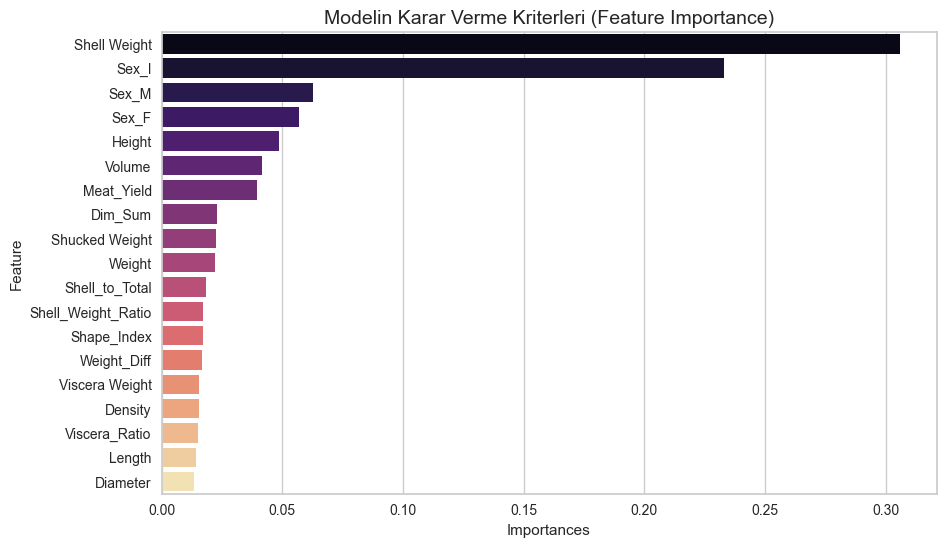

In [46]:
#Grafik Oluşturma
plt.figure(figsize=(10, 6))
sns.barplot(data=fi, x='Importances', y='Feature', palette='magma')
plt.title('Modelin Karar Verme Kriterleri (Feature Importance)', fontsize=14)
plt.show()

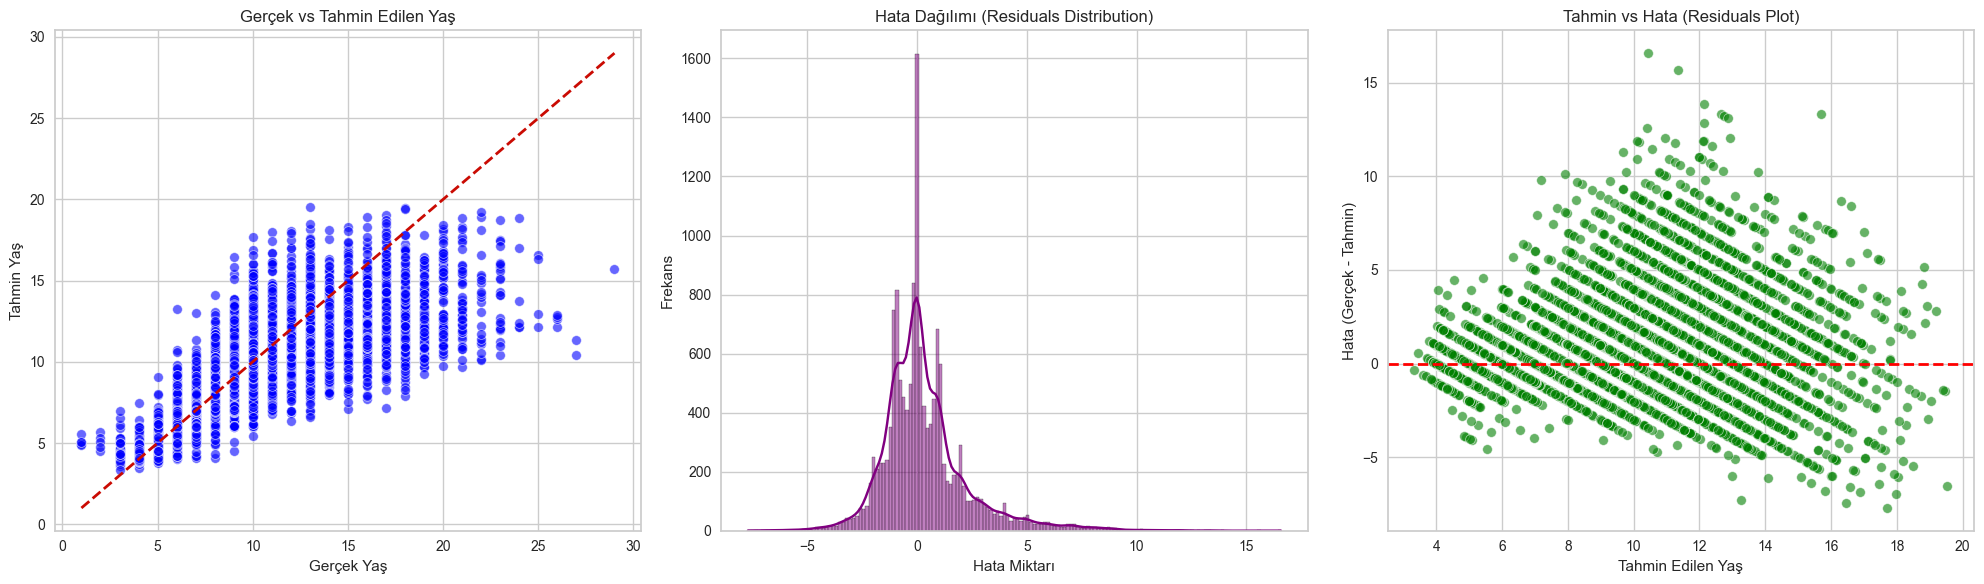

In [49]:
# 1. Residuals (Artıklar/Hatalar) Hesabı
residuals = y_test_real - tahmin_real

# Grafik alanı oluşturma (3 grafik yan yana)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- GRAFİK 1: GERÇEK VS TAHMİN ---
sns.scatterplot(x=y_test_real, y=tahmin_real, ax=axes[0], alpha=0.6, color='blue')
axes[0].plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=2)
axes[0].set_title('Gerçek vs Tahmin Edilen Yaş')
axes[0].set_xlabel('Gerçek Yaş')
axes[0].set_ylabel('Tahmin Yaş')

# --- GRAFİK 2: HATA DAĞILIMI (Error Analysis) ---
# Gerçek değerler ile modelin tahminleri arasındaki farkı (hatayı) hesaplar.
# Pozitif değer: Gerçek yaş tahminden yüksek. Negatif değer: Gerçek yaş tahminden düşük.
sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Hata Dağılımı (Residuals Distribution)')
axes[1].set_xlabel('Hata Miktarı')
axes[1].set_ylabel('Frekans')

# --- GRAFİK 3: RESIDUALS PLOT (Tahmin vs Hata) ---
sns.scatterplot(x=tahmin_real, y=residuals, ax=axes[2], alpha=0.6, color='green')
axes[2].axhline(y=0, color='red', linestyle='--', lw=2)
axes[2].set_title('Tahmin vs Hata (Residuals Plot)')
axes[2].set_xlabel('Tahmin Edilen Yaş')
axes[2].set_ylabel('Hata (Gerçek - Tahmin)')

plt.tight_layout()
plt.show()

In [51]:
import joblib

# Şampiyon modelini kaydet
joblib.dump(xgb_model, 'crab_age_xgb_model.pkl')
print("Model kaydedildi! 🦀")

Model kaydedildi! 🦀


# Test Verisini Hazırlama ve Tahmin

In [56]:
# Test dosyasını oku
df_test_final = pd.read_csv('test.csv')

In [57]:
df_test_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49368 entries, 0 to 49367
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              49368 non-null  int64  
 1   Sex             49368 non-null  object 
 2   Length          49368 non-null  float64
 3   Diameter        49368 non-null  float64
 4   Height          49368 non-null  float64
 5   Weight          49368 non-null  float64
 6   Shucked Weight  49368 non-null  float64
 7   Viscera Weight  49368 non-null  float64
 8   Shell Weight    49368 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 3.4+ MB


In [58]:
# --- ÖZELLİK MÜHENDİSLİĞİ ---
df_test_final['Volume'] = df_test_final['Length'] * df_test_final['Diameter'] * df_test_final['Height']
df_test_final['Shell_Weight_Ratio'] = df_test_final['Shell Weight'] / (df_test_final['Weight'] + 0.001)
df_test_final['Meat_Yield'] = df_test_final['Shucked Weight'] / (df_test_final['Weight'] + 0.001)
df_test_final['Density'] = df_test_final['Weight'] / (df_test_final['Volume'] + 0.001)
df_test_final['Weight_Diff'] = df_test_final['Weight'] - (df_test_final['Shucked Weight'] + df_test_final['Viscera Weight'] + df_test_final['Shell Weight'])
df_test_final['Dim_Sum'] = df_test_final['Length'] + df_test_final['Diameter'] + df_test_final['Height']
df_test_final['Shell_to_Total'] = df_test_final['Shell Weight'] / (df_test_final['Weight'] + 0.001)
df_test_final['Shape_Index'] = df_test_final['Length'] / (df_test_final['Height'] + 0.001)
df_test_final['Viscera_Ratio'] = df_test_final['Viscera Weight'] / (df_test_final['Weight'] + 0.001)

# 1. Cinsiyet verilerini (Dummies) hazırla
df_test_final = pd.get_dummies(df_test_final, columns=['Sex'])

# 2. EĞİTİMDEKİ SÜTUN SIRASINI KONTROL ET VE EKSİKLERİ TAMAMLA
# feature_columns: Train aşamasında x.columns.tolist() olarak kaydettiğimiz liste olmalı
for col in feature_columns:
    if col not in df_test_final.columns:
        df_test_final[col] = 0

# 3. BURASI ÇOK KRİTİK: Drop yapmak yerine, sadece modelin beklediği sütunları ve sırayı seç!
# Bu satır sayesinde id veya fazlalık sütunlar otomatik dışarıda kalır, sıra düzelir.
x_test_kaggle = df_test_final[feature_columns]

# 4. Tahmin ve Dosya Oluşturma (Logaritmik dönüşüm varsa expm1 şart)
tahmin_log = xgb_model.predict(x_test_kaggle.astype(float))
tahmin_gercek = np.expm1(tahmin_log)

# 5. Final Tablosunu Oluştur
submission = pd.DataFrame({
    'id': df_test_final['id'],
    'Age': tahmin_gercek
})

# Dosyayı kaydet
submission.to_csv('submission_crab_final_v2.csv', index=False)

print("🏁 Sütunlar hizalandı, id dışarıda bırakıldı ve submission hazır!")

🏁 Sütunlar hizalandı, id dışarıda bırakıldı ve submission hazır!


In [59]:
submission

,id,Age
0,74051,7.303828
1,74052,7.941536
2,74053,10.217208
3,74054,9.193475
4,74055,7.316135
...,...,...
49363,123414,9.008735
49364,123415,7.820565
49365,123416,13.409816
49366,123417,9.711323
